# E-Commerce Sales Analysis
**Author:** Taimoor Ali  
**Dataset:** Superstore Sales Dataset (Kaggle)  
**Tools:** Python, Pandas, Matplotlib, Seaborn

---

## Project Goal
Perform exploratory data analysis on a US retail superstore dataset to uncover:
- Which product categories generate the most sales
- How sales trend over time (monthly)
- Which states/regions perform best
- How discounts affect profitability


---
## Day 2 — Load & Explore the Data

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Nice plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load the dataset
# Make sure 'Sample - Superstore.csv' is in the same folder as this notebook
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# First look at the data
print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (9994, 21)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Understand data types and basic statistics
print('Data types:')
print(df.info())
print('\nBasic statistics:')
df.describe()

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantit

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


---
## Day 3 — Clean the Data

In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f'\nDuplicates removed: {before - after}')

# Extract useful time columns
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

print('\nData is clean!')
print('Final shape:', df.shape)

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicates removed: 0

Data is clean!
Final shape: (9994, 23)


---
## Days 4–5 — Visualizations

We will build **4 charts** that tell a clear data story.

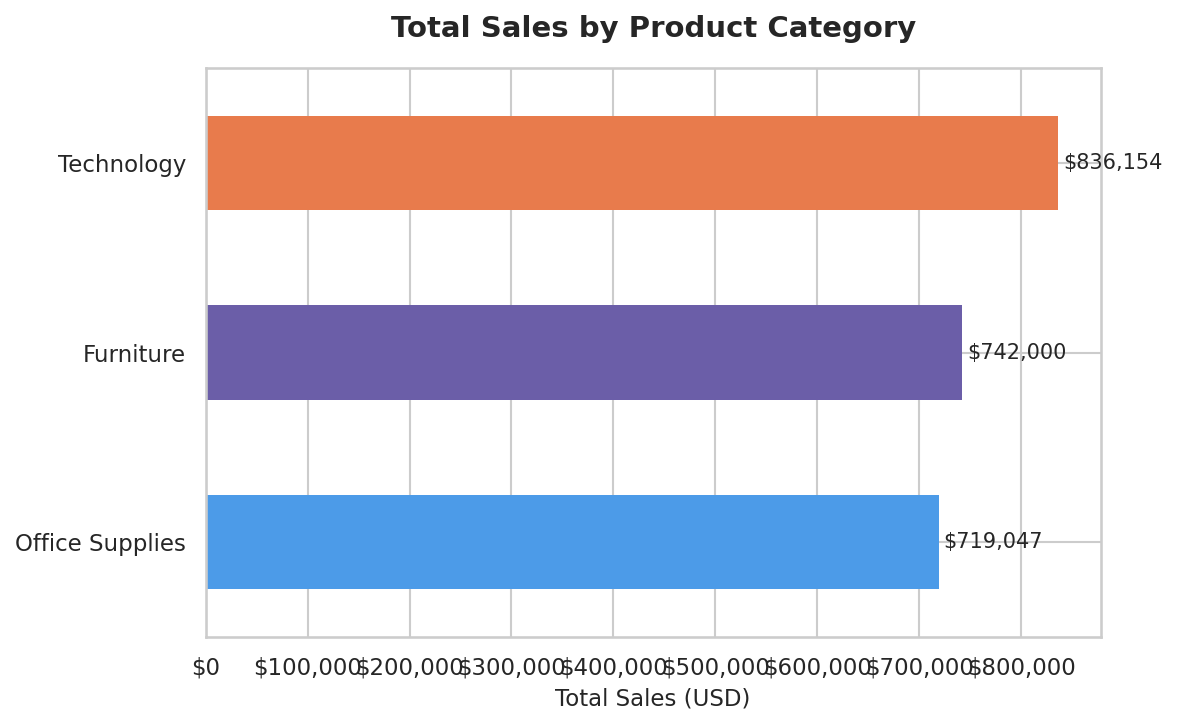

Chart 1 saved!


In [5]:
# CHART 1: Sales by Category 
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C9BE8', '#6B5EA8', '#E87B4C']
category_sales.plot(kind='barh', ax=ax, color=colors, edgecolor='none')

ax.set_title('Total Sales by Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales (USD)', fontsize=11)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add value labels on bars
for i, v in enumerate(category_sales):
    ax.text(v + 5000, i, f'${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart1_category_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved!')

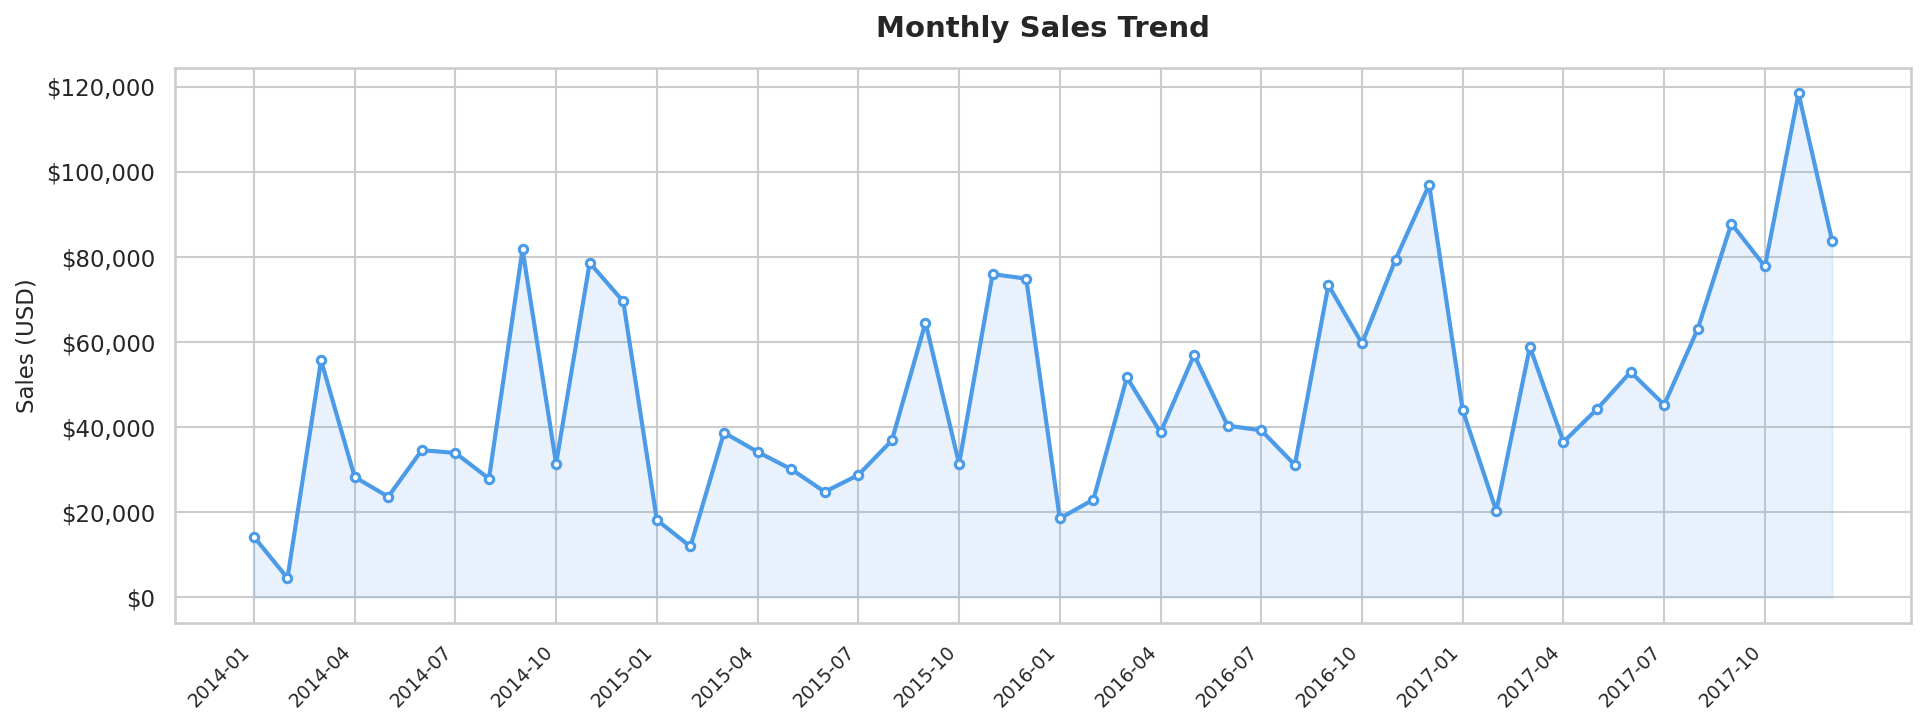

Chart 2 saved!


In [6]:
# CHART 2: Monthly Sales Trend 
monthly = df.groupby('Month')['Sales'].sum()
monthly.index = monthly.index.astype(str)  # convert Period to string for plotting

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly.values, color='#4C9BE8', linewidth=2,
        marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1.5)
ax.fill_between(monthly.index, monthly.values, alpha=0.12, color='#4C9BE8')

ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Sales (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels(monthly.index[::3], rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved!')

C:\Users\Ali\AppData\Local\Temp\ipykernel_169048\3201494407.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_states.index, rotation=30, ha='right', fontsize=10)


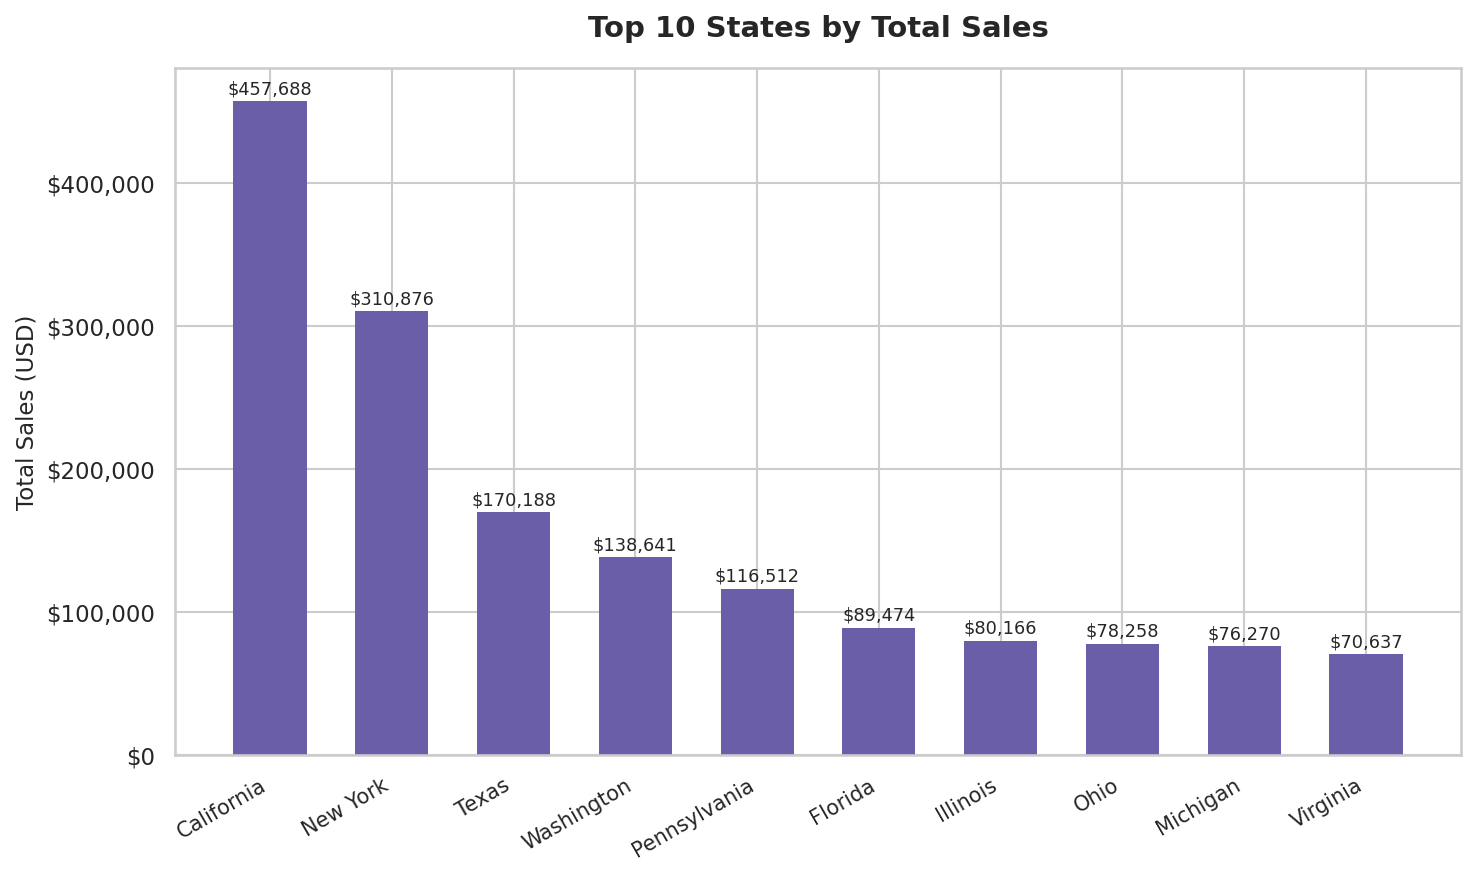

Chart 3 saved!


In [7]:
#  CHART 3: Top 10 States by Sales 
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(top_states.index, top_states.values,
              color='#6B5EA8', edgecolor='none', width=0.6)

ax.set_title('Top 10 States by Total Sales', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Sales (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticklabels(top_states.index, rotation=30, ha='right', fontsize=10)

# Add value labels on top of each bar
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 2000,
            f'${h:,.0f}', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.savefig('chart3_top_states.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved!')

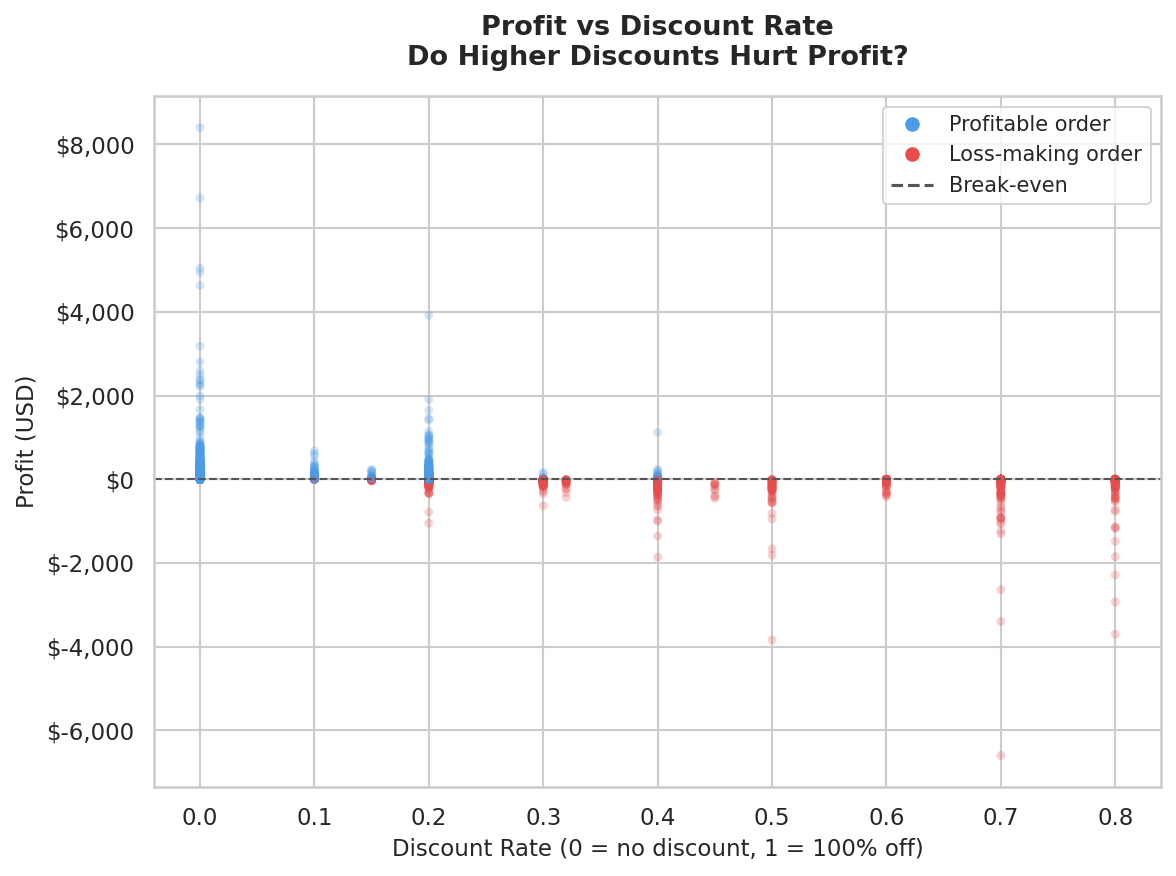

Chart 4 saved!


In [8]:
#  CHART 4: Profit vs Discount 
fig, ax = plt.subplots(figsize=(8, 6))

# Color points by profit (positive = blue, negative = red)
colors_scatter = df['Profit'].apply(lambda x: '#4C9BE8' if x >= 0 else '#E84C4C')
ax.scatter(df['Discount'], df['Profit'], alpha=0.25, c=colors_scatter, s=18, edgecolors='none')
ax.axhline(y=0, color='#555', linestyle='--', linewidth=1, label='Break-even line')

ax.set_title('Profit vs Discount Rate\nDo Higher Discounts Hurt Profit?',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Discount Rate (0 = no discount, 1 = 100% off)', fontsize=11)
ax.set_ylabel('Profit (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C9BE8', markersize=8, label='Profitable order'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E84C4C', markersize=8, label='Loss-making order'),
    Line2D([0], [0], color='#555', linestyle='--', label='Break-even')
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig('chart4_profit_discount.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved!')

---
## Key Findings Summary

After analysing the dataset, here are the main insights:

1. **Technology** products generate the highest total sales, followed by Furniture and Office Supplies.
2. **Sales peak** at the end of each year (Q4), likely due to holiday season demand.
3. **California** is by far the top-performing state, followed by New York and Texas.
4. **Higher discounts clearly reduce profitability** — orders with discounts above 0.4 (40%) are almost always loss-making. This is a key business insight.

> These findings can help an e-commerce business decide where to invest marketing spend and how to set discount policies more carefully.

---
*Analysis by Taimoor Ali | BS Mathematics, University of Jhang | taimoorali5588@gmail.com*